# Audio & Speech EDA
Portuguese presidential debate dataset — 28 debate videos, 2656 audio segments, 8 candidates.

**Main questions:**
1. What do the acoustic features look like globally?
2. Do speaker embeddings separate the 3 speakers in each debate?
3. Can we match those clusters back to named candidates across debates?
4. What does the cleanest debate (`Martins_vs_Gouveia_Melo_November_23`) reveal in detail?
5. What candidate-level acoustic patterns and transcript-level patterns emerge across the campaign?

**Notebook structure:**
- Part I — audio dataset loading and feature setup
- Part II — global acoustic feature EDA
- Part III — speaker separation from embeddings
- Part IV — cross-debate speaker labeling
- Part V — single-debate case study: Martins vs Gouveia Melo
- Part VI — across-candidate acoustic profiles
- Part VII — transcript EDA: quality, lexical patterns, and semantic structure

## Part I — Audio dataset loading and feature setup

In [ ]:
import sys
sys.path.insert(0, 'multivideo_analysis')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

%load_ext autoreload
%autoreload 2
from pipelines import (build_labeled_audio, extract_candidates,
                       CANDIDATES, KEY_FEATURES, NON_REDUNDANT, CAND_COLOR)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
FEATURES_DIR = 'Project_Features'

In [ ]:
data = build_labeled_audio()
print(f'Columns: {list(data.columns)}')

In [ ]:
debate_videos     = sorted(v for v in data['video'].unique() if 'vs' in v)
candidate_to_party = (data[data['speaker'].isin(CANDIDATES)]
                      .drop_duplicates('speaker')
                      .set_index('speaker')['party']
                      .to_dict())

print(f'Debate videos : {len(debate_videos)}')
print(f'Party mapping : {candidate_to_party}')

## Part II — Global acoustic feature overview

30 scalar features fall into 4 groups:
- **Pitch**: `meanF0Hz`, `stdevF0Hz`
- **Voice quality**: `HNR`, jitter family, shimmer family
- **Formants**: `f1_mean` through `f4_mean`, `fdisp`, `avgFormant`, `pF`, `mff`
- **Speech rate**: `speechrate`, `articulationrate`, `npause`, `asd`

We use a representative subset (`KEY_FEATURES`) for grouped plots. The next steps ask two simple EDA questions:
1. how are these features distributed overall?
2. which of them are redundant or strongly coupled?

In [ ]:
META = ['video', 'time stamp', 'duration', 'speak_embeddings', 'cluster_k3', 'speaker', 'party']
scalar_cols = [c for c in data.columns if c not in META]

print('Key features:', KEY_FEATURES)
print(f'Total scalar features: {len(scalar_cols)}')

### 2.1 Distribution of core acoustic features

In [ ]:
data[KEY_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
meanF0Hz,2656.0,153.812,31.455,84.690,129.671,149.873,177.109,235.532
stdevF0Hz,2656.0,33.276,9.977,9.947,26.100,32.623,39.792,72.745
HNR,2656.0,10.508,1.855,2.452,9.353,10.529,11.745,16.450
localJitter,2656.0,0.028,0.005,0.014,0.026,0.029,0.032,0.045
localShimmer,2656.0,0.111,0.017,0.067,0.099,0.110,0.122,0.169
speechrate,2656.0,4.740,0.601,2.126,4.359,4.755,5.127,6.914
articulationrate,2656.0,5.014,0.501,3.025,4.697,5.027,5.349,6.914
npause,2656.0,2.595,3.488,0.000,0.000,1.000,3.000,44.000
asd,2656.0,0.202,0.021,0.145,0.187,0.199,0.213,0.331
f1_mean,2656.0,459.627,44.087,346.147,427.024,455.753,487.726,650.846


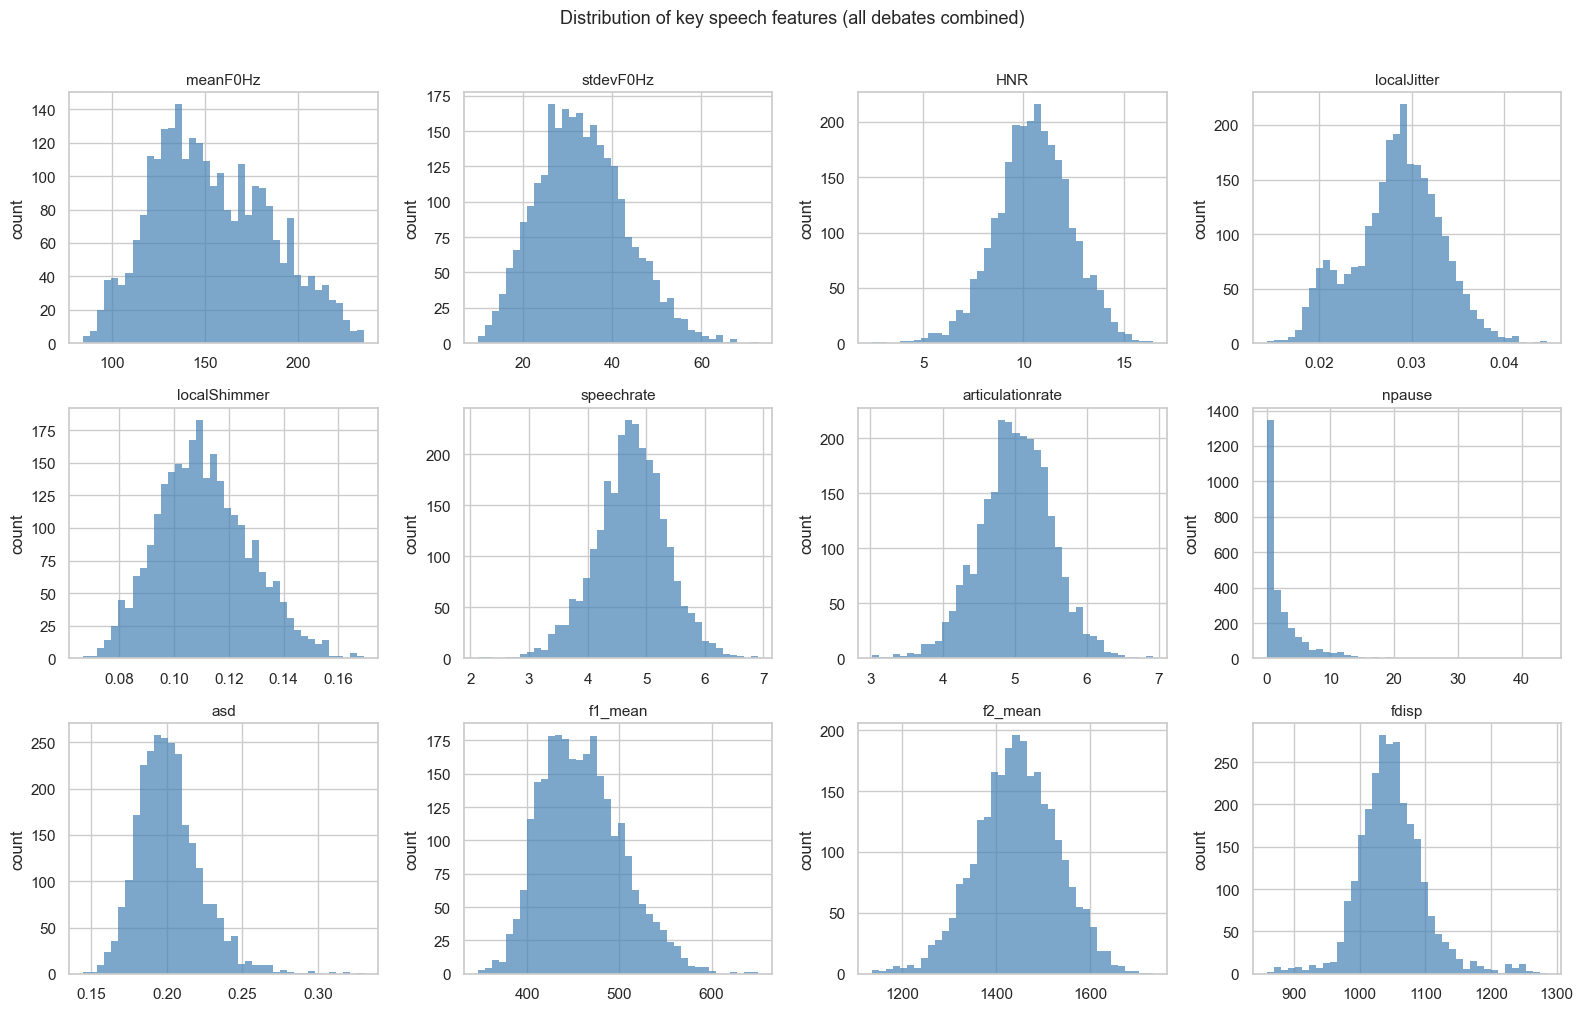

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    axes[i].hist(data[col].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('count')

plt.suptitle('Distribution of key speech features (all debates combined)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Correlation structure and feature redundancy

Which features move together? Strong within-group correlations (jitter variants, formant variants) confirm redundancy.
Cross-group correlations (e.g. pitch vs. jitter) are more informative.

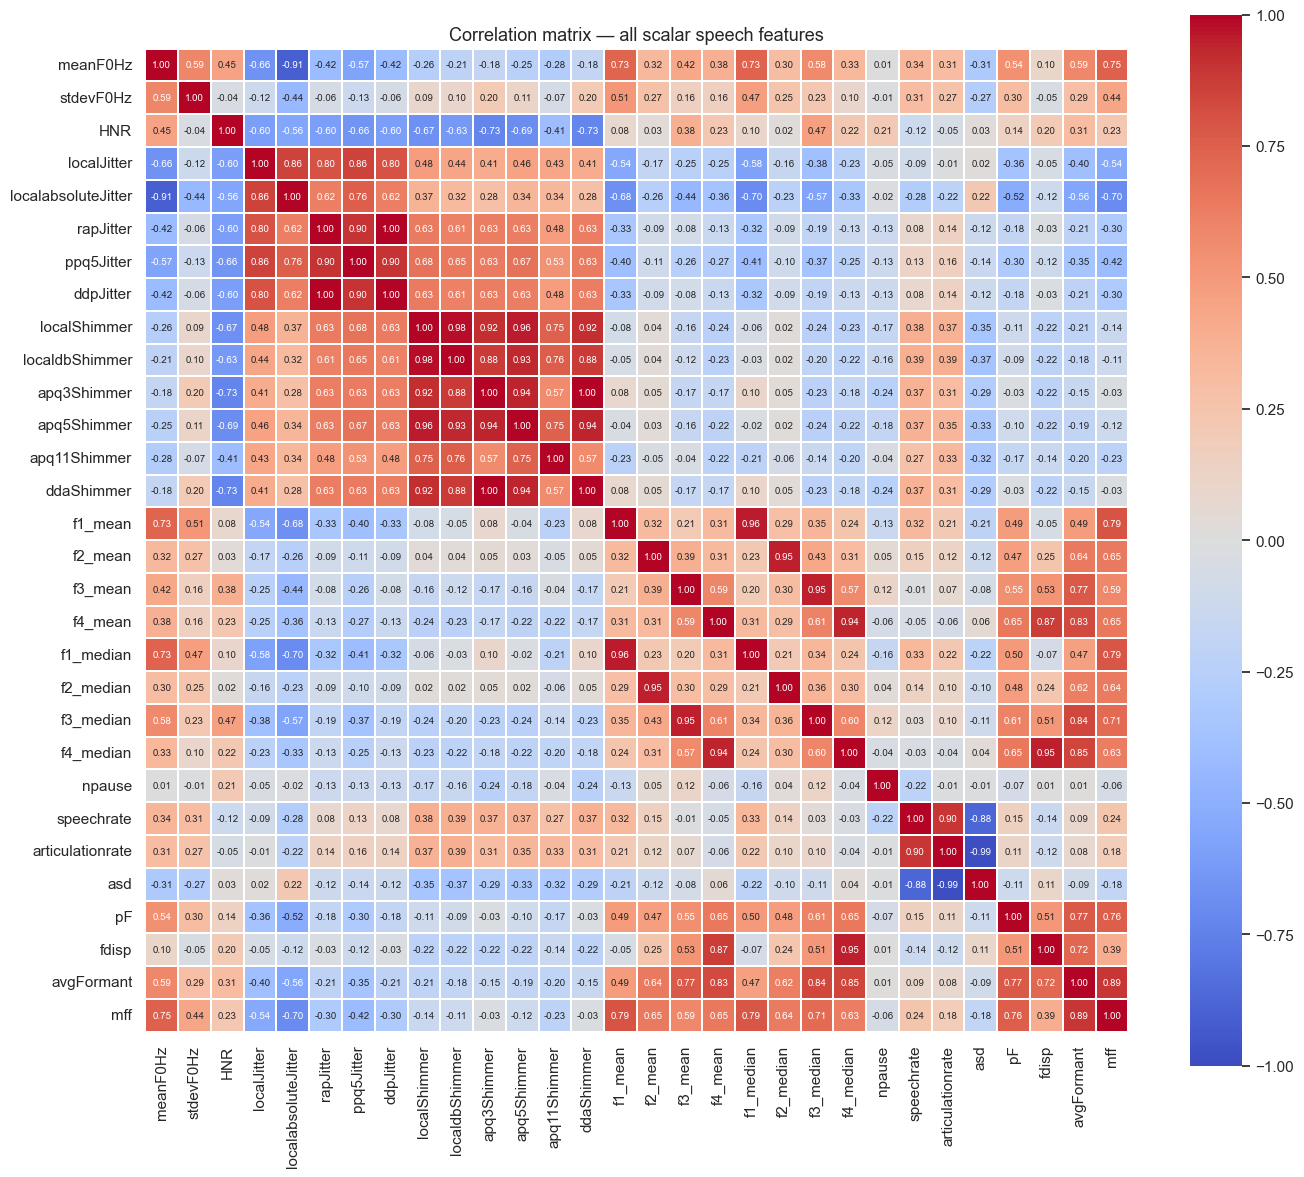

In [ ]:
corr = data[scalar_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlation matrix — all scalar speech features', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Top non-trivial cross-feature correlations (|r| > 0.4, no self-correlations)
corr_vals = corr.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0]

seen = set()
rows = []
for (a, b), v in corr_vals.sort_values(ascending=False).items():
    key = tuple(sorted([a, b]))
    if key not in seen and v > 0.4:
        seen.add(key)
        rows.append({'feature_a': a, 'feature_b': b, 'correlation': round(corr.loc[a, b], 3)})

pd.DataFrame(rows)

,feature_a,feature_b,correlation
0,apq3Shimmer,ddaShimmer,1.000
1,asd,articulationrate,-0.986
2,localShimmer,localdbShimmer,0.977
3,localShimmer,apq5Shimmer,0.959
4,f1_median,f1_mean,0.956
...,...,...,...
130,ddpJitter,meanF0Hz,-0.416
131,HNR,apq11Shimmer,-0.412
132,f1_median,ppq5Jitter,-0.408
133,apq3Shimmer,localJitter,0.406


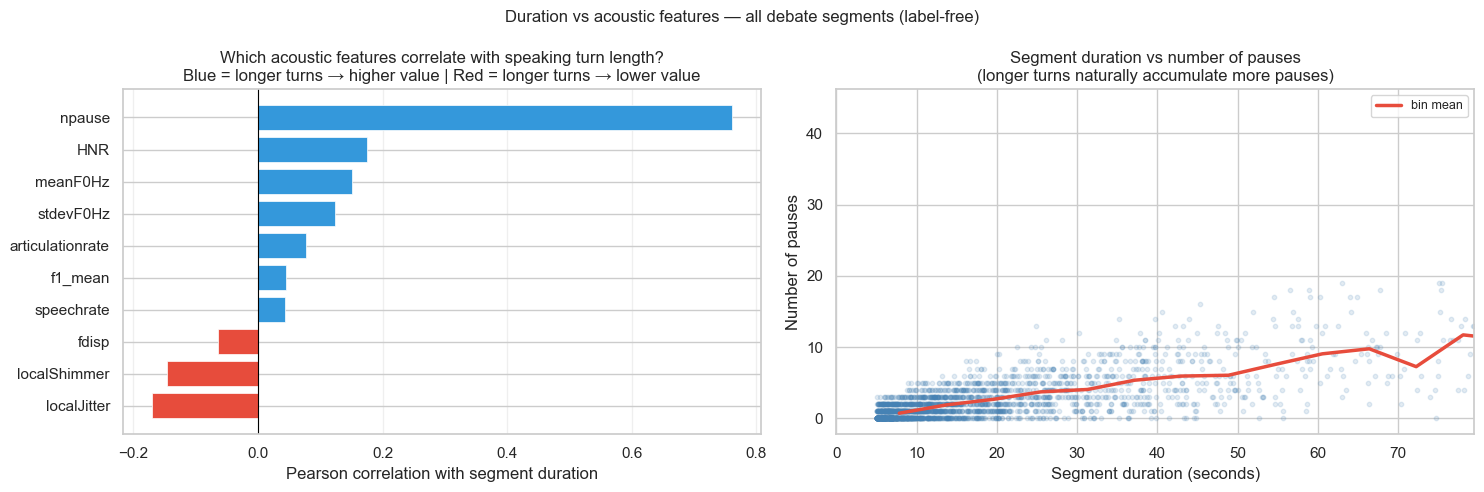

Pearson correlations: segment duration vs acoustic features
(computed on all debate segments, no speaker labels used)

  npause                r = +0.761   ↑ longer → higher
  HNR                   r = +0.176   ↑ longer → higher
  localJitter           r = -0.170   ↓ longer → lower
  meanF0Hz              r = +0.151   ↑ longer → higher
  localShimmer          r = -0.146   ↓ longer → lower
  stdevF0Hz             r = +0.123   ↑ longer → higher
  articulationrate      r = +0.077   ↑ longer → higher
  fdisp                 r = -0.064   ↓ longer → lower
  f1_mean               r = +0.046   ↑ longer → higher
  speechrate            r = +0.043   ↑ longer → higher


In [ ]:
# ── CELL: Correlation between segment duration and acoustic features ──────────
# Label-free. Does how long someone speaks in a turn correlate with
# how they sound? Longer turns may show lower pitch (fatigue/relaxation),
# more pauses, different shimmer.
# We use only debate segments to avoid newscast contamination.

debate_data_all = data[data['video'].isin(debate_videos)].copy()

DURATION_FEATURES = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer',
    'speechrate', 'articulationrate', 'npause', 'f1_mean', 'fdisp'
]

# ── Correlation bar chart: duration vs each feature ──────────────────────────
duration_corrs = {
    feat: debate_data_all['duration'].corr(debate_data_all[feat])
    for feat in DURATION_FEATURES
}
corr_series = pd.Series(duration_corrs).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_bar = ['#e74c3c' if v < 0 else '#3498db' for v in corr_series.values]
axes[0].barh(corr_series.index, corr_series.values,
             color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Pearson correlation with segment duration')
axes[0].set_title('Which acoustic features correlate with speaking turn length?\n'
                  'Blue = longer turns → higher value | Red = longer turns → lower value')
axes[0].grid(axis='x', alpha=0.3)

# ── Scatter: duration vs npause (strongest expected correlation) ──────────────
axes[1].scatter(
    debate_data_all['duration'],
    debate_data_all['npause'],
    alpha=0.15, s=10, color='steelblue', rasterized=True
)
# Add a smoothed trend line using rolling mean on binned data
bins = pd.cut(debate_data_all['duration'], bins=30)
trend = debate_data_all.groupby(bins, observed=True)['npause'].mean()
bin_centers = [interval.mid for interval in trend.index]
axes[1].plot(bin_centers, trend.values, color='#e74c3c', linewidth=2.5, label='bin mean')

axes[1].set_xlabel('Segment duration (seconds)')
axes[1].set_ylabel('Number of pauses')
axes[1].set_title('Segment duration vs number of pauses\n(longer turns naturally accumulate more pauses)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, debate_data_all['duration'].quantile(0.98))

plt.suptitle('Duration vs acoustic features — all debate segments (label-free)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Print the correlation table ───────────────────────────────────────────────
print('Pearson correlations: segment duration vs acoustic features')
print('(computed on all debate segments, no speaker labels used)')
print()
for feat, r in corr_series.sort_values(key=abs, ascending=False).items():
    direction = '↑ longer → higher' if r > 0 else '↓ longer → lower'
    print(f'  {feat:<20}  r = {r:+.3f}   {direction}')

## Part V — Single-debate case study: Martins vs Gouveia Melo

We validate on `Martins_vs_Gouveia_Melo_November_23` — the highest silhouette score (0.692),
meaning the cleanest three-cluster separation.

This part contains three complementary views:
1. label validation in embedding space + speaking time split
2. temporal turn-taking through the debate
3. a focused acoustic comparison of `Martins`, `Gouveia_Melo`, and the `host`

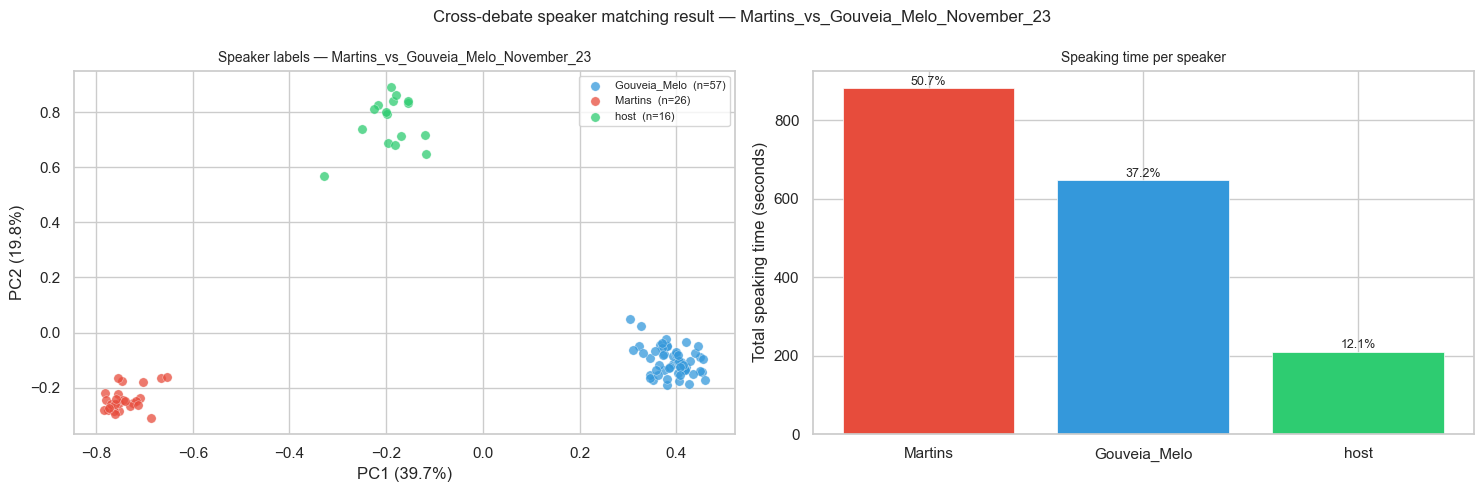


Speaking time summary for Martins_vs_Gouveia_Melo_November_23:
  Martins                     882.7s  (50.7%)  —  26 segments
  Gouveia_Melo                647.7s  (37.2%)  —  57 segments
  host                        210.4s  (12.1%)  —  16 segments


In [ ]:
DEBATE = 'Martins_vs_Gouveia_Melo_November_23'

debate_data = data[data['video'] == DEBATE].copy().reset_index(drop=True)
E = np.stack(debate_data['speak_embeddings'].values)

pca = PCA(n_components=2, random_state=42)
E_2d = pca.fit_transform(E)

speakers = debate_data['speaker'].values
unique_speakers = sorted(set(speakers))
colors = {'Martins': '#e74c3c', 'Gouveia_Melo': '#3498db', 'host': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for spk in unique_speakers:
    mask = speakers == spk
    ax.scatter(E_2d[mask, 0], E_2d[mask, 1],
               c=colors.get(spk, '#888888'), label=f'{spk}  (n={mask.sum()})',
               alpha=0.75, s=45, edgecolors='white', linewidth=0.3)
ax.set_title(f'Speaker labels — {DEBATE}', fontsize=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=8)

ax = axes[1]
time_per_speaker = debate_data.groupby('speaker')['duration'].sum().sort_values(ascending=False)
total_time = time_per_speaker.sum()

bars = ax.bar(
    time_per_speaker.index, time_per_speaker.values,
    color=[colors.get(s, '#888888') for s in time_per_speaker.index],
    edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, time_per_speaker.values):
    pct = val / total_time * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Total speaking time (seconds)')
ax.set_title('Speaking time per speaker', fontsize=10)

plt.suptitle(f'Cross-debate speaker matching result — {DEBATE}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nSpeaking time summary for {DEBATE}:')
for spk, t in time_per_speaker.items():
    pct = t / total_time * 100
    n   = (debate_data['speaker'] == spk).sum()
    print(f'  {spk:<25}  {t:6.1f}s  ({pct:.1f}%)  —  {n} segments')

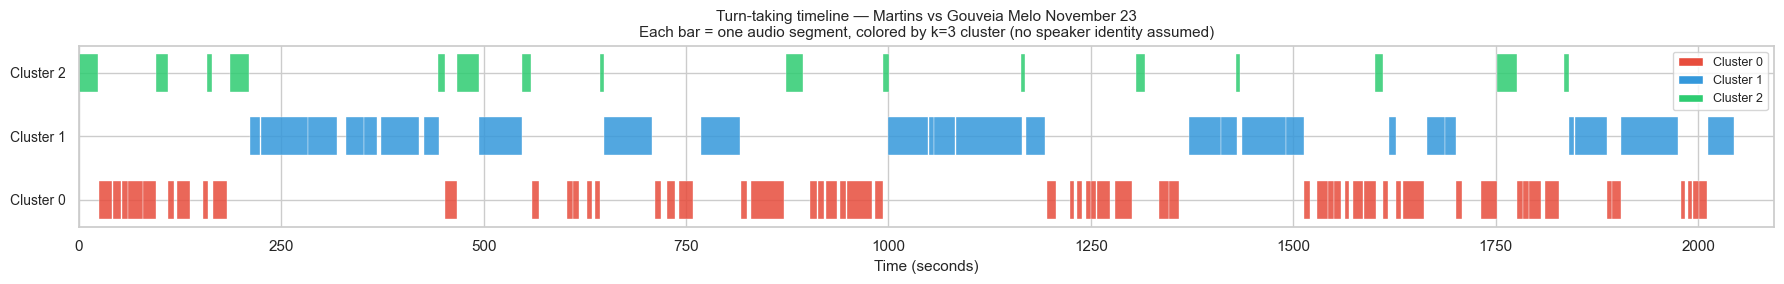

Turn statistics by cluster — Martins_vs_Gouveia_Melo_November_23:
  Cluster 0: 57 segments | mean duration 11.4s | median 8.7s | total 648s
  Cluster 1: 26 segments | mean duration 34.0s | median 29.3s | total 883s
  Cluster 2: 16 segments | mean duration 13.2s | median 10.4s | total 210s


In [ ]:
# ── CELL: Temporal turn-taking timeline ───────────────────────────────────────
# For one debate, plot each audio segment as a horizontal bar on a time axis.
# Colored by k=3 cluster label (no candidate names — purely geometric).
# Shows turn-taking rhythm, turn lengths, and whether one cluster (host)
# has visibly shorter and more evenly-spaced interjections.

TIMELINE_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'  # highest silhouette score

dbt = data[data['video'] == TIMELINE_DEBATE].copy().sort_values('time stamp').reset_index(drop=True)

# k=3 labels for this debate (already computed in cluster_k3 column)
cluster_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

fig, ax = plt.subplots(figsize=(18, 3))

for _, row in dbt.iterrows():
    c = int(row['cluster_k3'])
    ax.barh(
        y=c,
        width=row['duration'],
        left=row['time stamp'],
        height=0.6,
        color=cluster_colors[c],
        alpha=0.85,
        edgecolor='white',
        linewidth=0.3
    )

ax.set_yticks([0, 1, 2])
ax.set_yticklabels([cluster_labels[i] for i in [0, 1, 2]], fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_title(
    f'Turn-taking timeline — {TIMELINE_DEBATE.replace("_", " ")}\n'
    f'Each bar = one audio segment, colored by k=3 cluster (no speaker identity assumed)',
    fontsize=11
)
ax.set_xlim(0, dbt['time stamp'].max() + dbt['duration'].max())

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cluster_colors[i], label=cluster_labels[i]) for i in range(3)]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print basic turn stats per cluster
print(f'Turn statistics by cluster — {TIMELINE_DEBATE}:')
for c in [0, 1, 2]:
    sub = dbt[dbt['cluster_k3'] == c]
    print(f'  Cluster {c}: {len(sub)} segments | '
          f'mean duration {sub["duration"].mean():.1f}s | '
          f'median {sub["duration"].median():.1f}s | '
          f'total {sub["duration"].sum():.0f}s')

,segments,total_duration,mean_duration,median_duration,meanF0Hz_mean,meanF0Hz_median,stdevF0Hz_mean,stdevF0Hz_median,HNR_mean,HNR_median,speechrate_mean,speechrate_median,f1_mean_mean,f1_mean_median,f2_mean_mean,f2_mean_median
speaker,,,,,,,,,,,,,,,,
Martins,26,882.731,33.951,29.328,220.554,222.889,39.499,40.813,12.764,12.851,4.908,4.978,528.006,528.805,1417.267,1417.131
Gouveia_Melo,57,647.696,11.363,8.674,135.160,133.878,27.148,27.696,10.051,10.191,4.175,4.145,431.575,429.597,1358.896,1359.394
host,16,210.449,13.153,10.420,178.609,179.194,31.278,30.376,11.494,11.337,4.912,4.867,505.067,502.681,1489.114,1495.879


C:\Users\dinis\AppData\Local\Temp\ipykernel_14428\4115561377.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_14428\4115561377.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_14428\4115561377.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_14428\4115561377.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

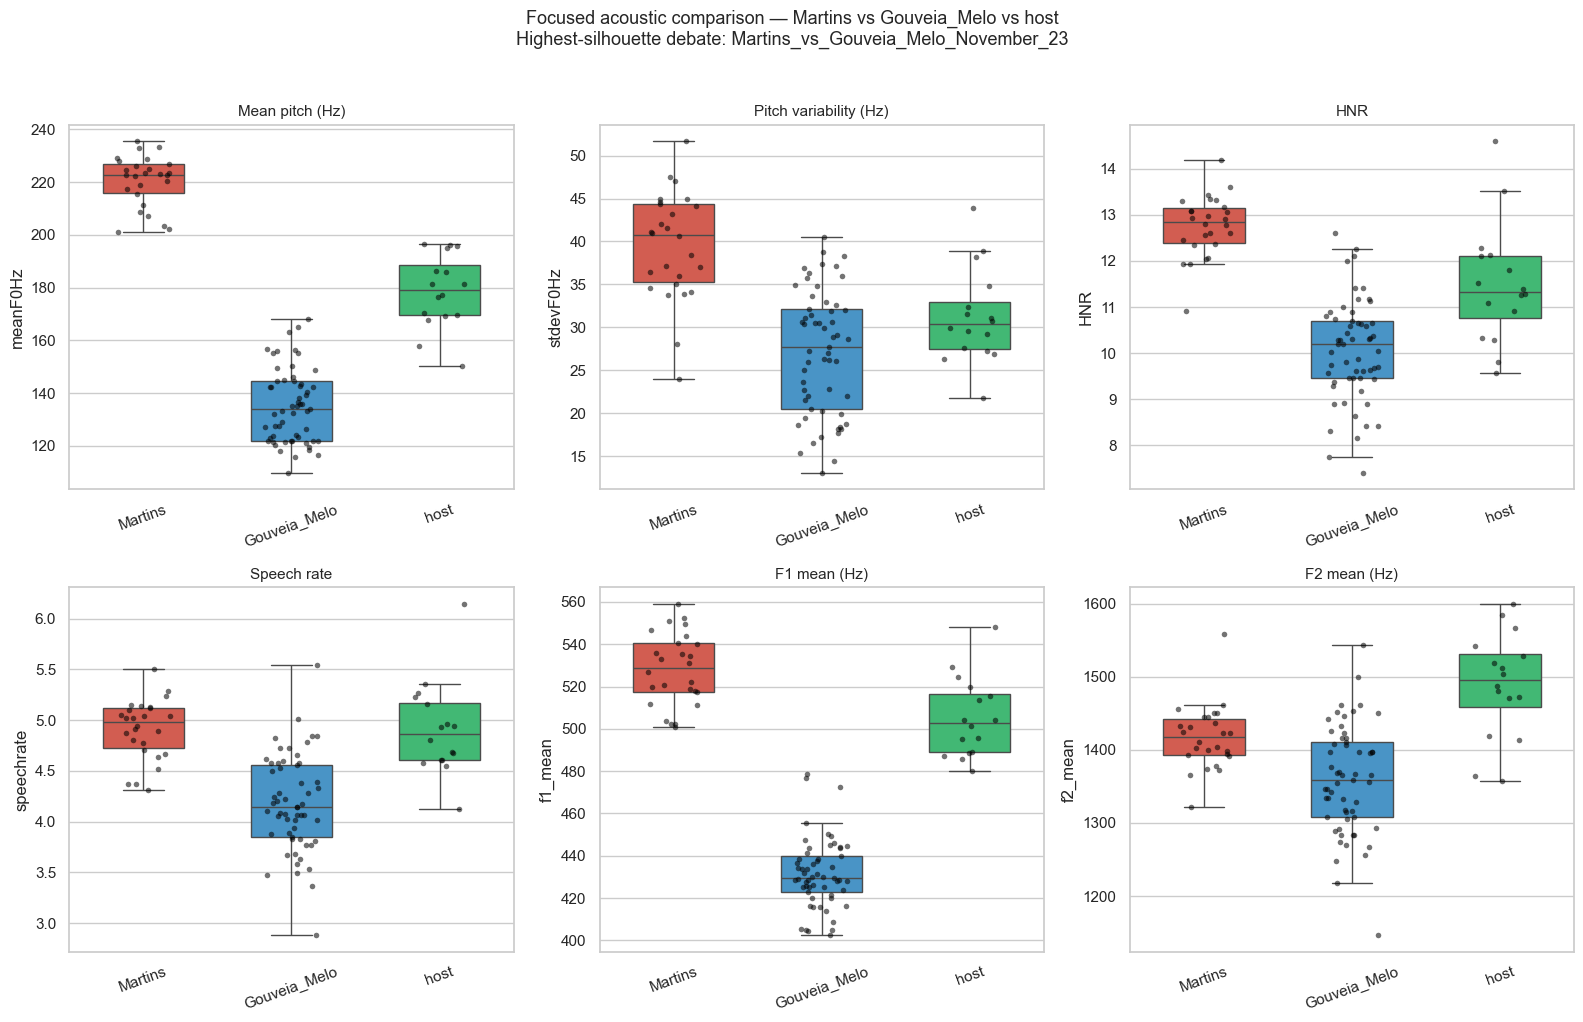

,feature,label,pair,median_a,median_b,mannwhitney_p,cliffs_delta
6,HNR,HNR,Martins vs Gouveia_Melo,12.8508,10.1913,0.0000,0.9595
8,HNR,HNR,Gouveia_Melo vs host,10.1913,11.3370,0.0001,-0.6250
7,HNR,HNR,Martins vs host,12.8508,11.3370,0.0004,0.6587
12,f1_mean,F1 mean (Hz),Martins vs Gouveia_Melo,528.8047,429.5972,0.0000,1.0000
14,f1_mean,F1 mean (Hz),Gouveia_Melo vs host,429.5972,502.6809,0.0000,-1.0000
13,f1_mean,F1 mean (Hz),Martins vs host,528.8047,502.6809,0.0008,0.6250
17,f2_mean,F2 mean (Hz),Gouveia_Melo vs host,1359.3941,1495.8791,0.0000,-0.7895
15,f2_mean,F2 mean (Hz),Martins vs Gouveia_Melo,1417.1312,1359.3941,0.0004,0.4899
16,f2_mean,F2 mean (Hz),Martins vs host,1417.1312,1495.8791,0.0015,-0.5913
0,meanF0Hz,Mean pitch (Hz),Martins vs Gouveia_Melo,222.8894,133.8776,0.0000,1.0000


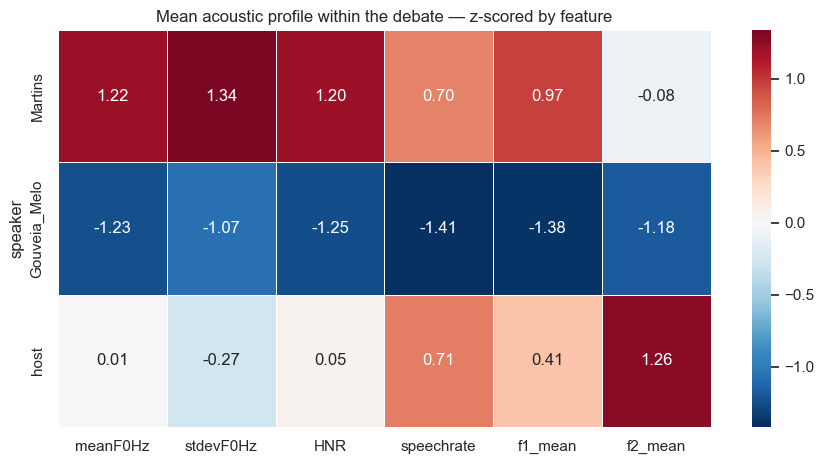

Host profile distance in z-scored feature space (smaller = more similar):
speaker
Martins         2.731
Gouveia_Melo    4.194



,feature,label,host_mean,closest_to_host,abs_diff
0,meanF0Hz,Mean pitch (Hz),178.609,Martins,41.946
1,stdevF0Hz,Pitch variability (Hz),31.278,Gouveia_Melo,4.130
2,HNR,HNR,11.494,Martins,1.271
3,speechrate,Speech rate,4.912,Martins,0.004
4,f1_mean,F1 mean (Hz),505.067,Martins,22.939
5,f2_mean,F2 mean (Hz),1489.114,Martins,71.847


Interpretation note: if the host is closer to Martins on pitch/formants, that may suggest
a more similar vocal profile in this debate, but it is not enough to infer exact gender or age.


In [ ]:
# ── CELL: Focused acoustic comparison — Martins vs Gouveia_Melo vs host ─────
# Descriptive only: acoustic similarity can suggest vocal-profile overlap,
# but it does NOT identify a speaker's gender or age with certainty.

from scipy.stats import mannwhitneyu

FOCUS_DEBATE = 'Martins_vs_Gouveia_Melo_November_23'
FOCUS_SPEAKERS = ['Martins', 'Gouveia_Melo', 'host']
FOCUS_FEATURES = [
    ('meanF0Hz',  'Mean pitch (Hz)'),
    ('stdevF0Hz', 'Pitch variability (Hz)'),
    ('HNR',       'HNR'),
    ('speechrate','Speech rate'),
    ('f1_mean',   'F1 mean (Hz)'),
    ('f2_mean',   'F2 mean (Hz)'),
]

focus_palette = {'Martins': '#e74c3c', 'Gouveia_Melo': '#3498db', 'host': '#2ecc71'}
focus_order = FOCUS_SPEAKERS

focus_data = data[
    (data['video'] == FOCUS_DEBATE) &
    (data['speaker'].isin(FOCUS_SPEAKERS))
].copy()

focus_summary = focus_data.groupby('speaker').agg(
    segments=('duration', 'size'),
    total_duration=('duration', 'sum'),
    mean_duration=('duration', 'mean'),
    median_duration=('duration', 'median')
)
for feat, _ in FOCUS_FEATURES:
    focus_summary[f'{feat}_mean'] = focus_data.groupby('speaker')[feat].mean()
    focus_summary[f'{feat}_median'] = focus_data.groupby('speaker')[feat].median()
focus_summary = focus_summary.reindex(focus_order)

display(focus_summary.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, FOCUS_FEATURES):
    sns.boxplot(
        data=focus_data, x='speaker', y=feat,
        order=focus_order,
        palette=focus_palette,
        ax=ax, fliersize=0, width=0.55
    )
    sns.stripplot(
        data=focus_data, x='speaker', y=feat,
        order=focus_order,
        ax=ax, color='black', alpha=0.55, size=4, jitter=0.18
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle(
    'Focused acoustic comparison — Martins vs Gouveia_Melo vs host\n'
    'Highest-silhouette debate: Martins_vs_Gouveia_Melo_November_23',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    gt = sum((xi > y).sum() for xi in x)
    lt = sum((xi < y).sum() for xi in x)
    return (gt - lt) / (len(x) * len(y))

pairs = [
    ('Martins', 'Gouveia_Melo'),
    ('Martins', 'host'),
    ('Gouveia_Melo', 'host')
]

test_rows = []
for feat, label in FOCUS_FEATURES:
    for a, b in pairs:
        xa = focus_data.loc[focus_data['speaker'] == a, feat].dropna().values
        xb = focus_data.loc[focus_data['speaker'] == b, feat].dropna().values
        stat, p = mannwhitneyu(xa, xb, alternative='two-sided')
        delta = cliffs_delta(xa, xb)
        test_rows.append({
            'feature': feat,
            'label': label,
            'pair': f'{a} vs {b}',
            'median_a': np.median(xa),
            'median_b': np.median(xb),
            'mannwhitney_p': p,
            'cliffs_delta': delta
        })

tests_df = pd.DataFrame(test_rows).sort_values(['feature', 'mannwhitney_p'])
display(tests_df.round(4))

focus_profile = (
    focus_data.groupby('speaker')[[feat for feat, _ in FOCUS_FEATURES]]
    .mean()
    .reindex(focus_order)
)
focus_profile_z = pd.DataFrame(
    StandardScaler().fit_transform(focus_profile),
    index=focus_profile.index,
    columns=focus_profile.columns
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.heatmap(
    focus_profile_z,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.4,
    ax=ax
)
ax.set_title('Mean acoustic profile within the debate — z-scored by feature', fontsize=12)
plt.tight_layout()
plt.show()

host_vec = focus_profile_z.loc['host']
host_dist = ((focus_profile_z.drop(index='host') - host_vec) ** 2).sum(axis=1) ** 0.5
print('Host profile distance in z-scored feature space (smaller = more similar):')
print(host_dist.sort_values().round(3).to_string())
print()

closest_by_feature = []
for feat, label in FOCUS_FEATURES:
    host_mean = focus_profile.loc['host', feat]
    diffs = {
        spk: abs(focus_profile.loc[spk, feat] - host_mean)
        for spk in ['Martins', 'Gouveia_Melo']
    }
    closest = min(diffs, key=diffs.get)
    closest_by_feature.append({
        'feature': feat,
        'label': label,
        'host_mean': host_mean,
        'closest_to_host': closest,
        'abs_diff': diffs[closest]
    })
display(pd.DataFrame(closest_by_feature).round(3))

print('Interpretation note: if the host is closer to Martins on pitch/formants, that may suggest')
print('a more similar vocal profile in this debate, but it is not enough to infer exact gender or age.')
